In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Exercise 5 - The Verlet Method and Earth's Orbit.

Use the Verlet method to calculate the Earth's orbit around the Sun, which is described by the vector equations:

$$\frac{\text{d}^2\bf r}{\text{d}t^2}=-GM\frac{\bf r}{r^3},$$

where $G = 6.6738\times 10^{−11}$ m$^3$ kg$^{−1}$ s$^{−2}$ is Newton's universal gravitational constant and $M = 1.9891\times 10^{30}$ Kg is the mass of the Sun.

To set the initial conditions, note that at perihelion, the closest point of Earth's trajectory to the Sun, Earth moves perpendicular to the line connecting Earth and the Sun, at a distance of $1.4710\times 10^{11}$ m from the Sun with a linear speed of $3.0287\times 10^4$ m/s.

1. Write a program that calculates Earth's orbit using the Verlet method with $h=1$ h. Plot the trajectory so that the Earth completes several full revolutions around the Sun.

2. Modify the program to calculate the potential energy $− GMm/r$, with $m=5.9722\times 10^{24}$ kg the mass of Earth, the kinetic energy $mv^2/2$, and the total energy at each step. Plot these quantities and comment on the results.

3. Plot the total energy again and discuss the observed results. What does the Verlet method guarantee?


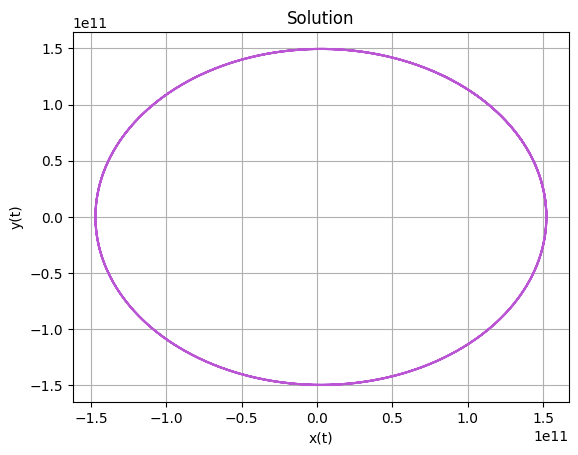

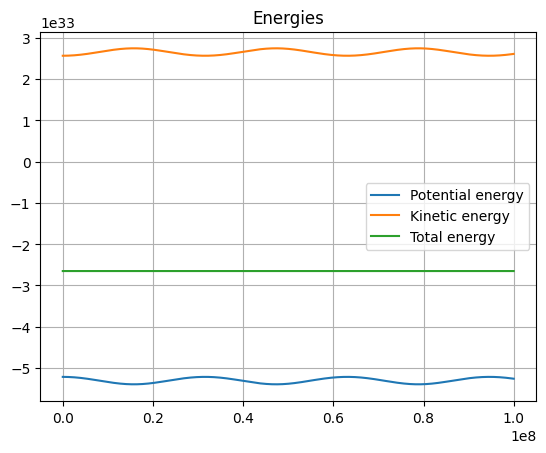

In [4]:
def F(r):
    G = 6.6738e-11
    M = 1.9891e30
    return -G * M * r / (np.sqrt(np.sum(r * r)) ** 3)


def V(r):
    G = 6.6738e-11
    M = 1.9891e30
    m = 5.9722e24
    return -G * M * m / np.sqrt(np.sum(r * r))


def T(v):
    m = 5.9722e24
    return 0.5 * m * np.sum(v * v)


def verlet(F, a, b, N, r, print = False):
    h = 3600

    pos = np.array([r[0], r[1]], float)
    vel = np.array([r[2], r[3]], float)
    v2 = vel + 0.5 * h * F(pos)

    tp = np.arange(a, b, h)
    xp = []
    yp = []
    Vp = []
    Tp = []
    Ep = []

    for t in tp:
        xp.append(pos[0])
        yp.append(pos[1])
        Vp.append(V(pos))
        Tp.append(T(vel))
        Ep.append(V(pos) + T(vel))

        pos += h * v2
        k = h * F(pos)
        vel = v2 + 0.5 * k
        v2 += k

    if print:
        plt.plot(xp, yp, color = mc)
        plt.xlabel("x(t)")
        plt.ylabel("y(t)")
        plt.title("Solution")
        plt.grid()
        plt.show()

        plt.plot(tp, Vp)
        plt.plot(tp, Tp)
        plt.plot(tp, Ep)
        plt.grid()
        plt.title("Energies")
        plt.legend(["Potential energy", "Kinetic energy", "Total energy"])
        plt.show()

    return tp, xp, yp, Vp, Tp, Ep


x0 = 1.5210e11
y0 = 0
vx0 = 0
vy0 = 2.9291e4

r = [x0, y0, vx0, vy0]
a = 0
b = 100e6
N = 27777.77778

t, x, y, V, T, E = verlet(F, a, b, N, r, True)
